# California State Procurement Data — Preparation for AI Agent

In [1]:
%matplotlib inline
import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pymongo import MongoClient, ASCENDING

plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

# Download latest version from Kaggle (requires kagglehub: pip install kagglehub)
path = kagglehub.dataset_download("sohier/large-purchases-by-the-state-of-ca")
print("Path to dataset files:", path)

# Find the CSV inside the downloaded folder
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
DATA_PATH = os.path.join(path, csv_file)
print("Loading:", csv_file)

df = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Loaded {len(df):,} rows x {len(df.columns)} columns")

c:\Users\SP7\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\SP7\.cache\kagglehub\datasets\sohier\large-purchases-by-the-state-of-ca\versions\1
Loading: PURCHASE ORDER DATA EXTRACT 2012-2015_0.csv
Loaded 346,018 rows x 31 columns


## 1. Basic Info

In [2]:
print(df.shape)

(346018, 31)


We have **346,018 purchase orders** and **31 columns** describing each one.

In [3]:
print(df.dtypes)

Creation Date               object
Purchase Date               object
Fiscal Year                 object
LPA Number                  object
Purchase Order Number       object
Requisition Number          object
Acquisition Type            object
Sub-Acquisition Type        object
Acquisition Method          object
Sub-Acquisition Method      object
Department Name             object
Supplier Code              float64
Supplier Name               object
Supplier Qualifications     object
Supplier Zip Code           object
CalCard                     object
Item Name                   object
Item Description            object
Quantity                   float64
Unit Price                  object
Total Price                 object
Classification Codes        object
Normalized UNSPSC          float64
Commodity Title             object
Class                      float64
Class Title                 object
Family                     float64
Family Title                object
Segment             

Most columns are stored as text (`object`). The ones that need fixing:
- **Total Price** and **Unit Price** — text because of `$`. Must be numbers for aggregation queries.
- **Creation Date** and **Purchase Date** — text. Must stay as native datetime objects for MongoDB date queries.

In [4]:
df.head(5)

,Creation Date,Purchase Date,Fiscal Year,LPA Number,Purchase Order Number,Requisition Number,Acquisition Type,Sub-Acquisition Type,Acquisition Method,Sub-Acquisition Method,...,Classification Codes,Normalized UNSPSC,Commodity Title,Class,Class Title,Family,Family Title,Segment,Segment Title,Location
0,08/27/2013,NaN,2013-2014,7-12-70-26,REQ0011118,REQ0011118,IT Goods,NaN,WSCA/Coop,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,01/29/2014,NaN,2013-2014,NaN,REQ0011932,REQ0011932,NON-IT Goods,NaN,Informal Competitive,NaN,...,76121504,76121504.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,11/01/2013,NaN,2013-2014,NaN,REQ0011476,REQ0011476,IT Services,NaN,Informal Competitive,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"95841\n(38.662263, -121.346136)"
3,06/13/2014,06/05/2014,2013-2014,NaN,4500236642,NaN,NON-IT Goods,NaN,Informal Competitive,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"91436\n(34.151642, -118.49051)"
4,03/12/2014,03/12/2014,2013-2014,1-10-75-60A,4500221028,NaN,NON-IT Goods,NaN,Statewide Contract,NaN,...,44103127,44103127.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"95814\n(38.580427, -121.494396)"


A quick look at the first 5 rows. Dates like `08/27/2013` and prices like `$1.00` are plain text and need cleaning before loading into MongoDB.

## 2. Data Quality

In [5]:
df.isnull().sum()

Creation Date                   0
Purchase Date               17436
Fiscal Year                     0
LPA Number                 253673
Purchase Order Number           0
Requisition Number         331649
Acquisition Type                0
Sub-Acquisition Type       277681
Acquisition Method              0
Sub-Acquisition Method     315122
Department Name                 0
Supplier Code                  36
Supplier Name                  36
Supplier Qualifications    204273
Supplier Zip Code           70110
CalCard                         0
Item Name                      32
Item Description              202
Quantity                       30
Unit Price                     30
Total Price                    30
Classification Codes         1017
Normalized UNSPSC            1017
Commodity Title              3295
Class                        3295
Class Title                  3295
Family                       3295
Family Title                 3295
Segment                      3295
Segment Title 

Key missing data:
- **Purchase Date** — 17,436 missing (~5%). Many orders have no delivery date.
- **Requisition Number** — 331,649 missing (~96%). Not reliable to query on.
- **LPA Number** — 253,673 missing (~73%). Same issue.
- **Item Name, Total Price, Unit Price** — fewer than 35 missing each. Very clean.

In [6]:
df.duplicated().sum()

np.int64(2084)

There are **2,084 duplicate rows**. We'll remove them in cleaning to avoid double-counting in aggregations.

## 3. Cleaning

In [7]:
# Remove $ and commas, convert prices to float
df['Total Price'] = df['Total Price'].str.replace(r'[\$,]', '', regex=True).astype(float)
df['Unit Price']  = df['Unit Price'].str.replace(r'[\$,]', '', regex=True).astype(float)

print(df[['Unit Price', 'Total Price']].head(5))

   Unit Price  Total Price
0        1.00         1.00
1        2.00         4.00
2      150.00       675.00
3         NaN          NaN
4     6080.26      6080.26


Prices are now real numbers. We can now calculate totals, averages, and run range queries.

In [8]:
# Convert dates to datetime — kept as datetime objects for native MongoDB date support
df['Creation Date'] = pd.to_datetime(df['Creation Date'], errors='coerce')
df['Purchase Date'] = pd.to_datetime(df['Purchase Date'], errors='coerce')

print(df[['Creation Date', 'Purchase Date']].dtypes)
print(df[['Creation Date', 'Purchase Date']].head(5))

Creation Date    datetime64[ns]
Purchase Date    datetime64[ns]
dtype: object
  Creation Date Purchase Date
0    2013-08-27           NaT
1    2014-01-29           NaT
2    2013-11-01           NaT
3    2014-06-13    2014-06-05
4    2014-03-12    2014-03-12


Dates are now proper datetime objects — **not strings**. MongoDB stores these as native ISODate, enabling filtering by month, year, quarter, or any date range.

In [9]:
# Normalize Item Name — lowercase and strip whitespace
df['Item Name'] = df['Item Name'].str.lower().str.strip()

# Strip whitespace from all string columns
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()

# Drop duplicates
df = df.drop_duplicates()
print(f"Rows after removing duplicates: {len(df):,}")

Rows after removing duplicates: 343,884


Item names are now all lowercase — "Toner" and "toner" count as one. Duplicates removed. Dataset is clean.

In [10]:
# Rename all columns to snake_case for machine-friendly MongoDB field names
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(r'[\s\-/]+', '_', regex=True)
    .str.replace(r'[^a-z0-9_]', '', regex=True)
)
print(list(df.columns))

['creation_date', 'purchase_date', 'fiscal_year', 'lpa_number', 'purchase_order_number', 'requisition_number', 'acquisition_type', 'sub_acquisition_type', 'acquisition_method', 'sub_acquisition_method', 'department_name', 'supplier_code', 'supplier_name', 'supplier_qualifications', 'supplier_zip_code', 'calcard', 'item_name', 'item_description', 'quantity', 'unit_price', 'total_price', 'classification_codes', 'normalized_unspsc', 'commodity_title', 'class', 'class_title', 'family', 'family_title', 'segment', 'segment_title', 'location']


All column names are now `snake_case`. The AI agent can reference field names directly in MongoDB queries without escaping.

In [11]:
# Add helper columns — year, month, quarter as separate integers (not combined strings)
# This makes MongoDB grouping and filtering much simpler:
#   Filter by year:    { year: 2014 }
#   Group by quarter:  { $group: { _id: { year: '$year', quarter: '$quarter' } } }
df['year']    = df['creation_date'].dt.year.astype('Int64')
df['month']   = df['creation_date'].dt.month.astype('Int64')
df['quarter'] = df['creation_date'].dt.quarter.astype('Int64')

print(df[['creation_date', 'year', 'month', 'quarter']].head(5))

  creation_date  year  month  quarter
0    2013-08-27  2013      8        3
1    2014-01-29  2014      1        1
2    2013-11-01  2013     11        4
3    2014-06-13  2014      6        2
4    2014-03-12  2014      3        1


Year, month, and quarter are stored as separate integers. This avoids string parsing in MongoDB and makes time-based aggregations fast and straightforward.

## 4. EDA — Exploratory Data Analysis

This section explores the dataset from the angle of the queries the AI agent will need to answer:
spending trends, top suppliers, most frequent items, time patterns, and category breakdowns.

### 4.1 Distribution of Total Price
*Supports queries like: "What is the typical order size?" or "Show me orders above $50,000."*

In [12]:
print(df['total_price'].describe())
print(f"\nSkewness : {df['total_price'].skew():.2f}")
print(f"Median   : ${df['total_price'].median():,.2f}")
print(f"Mean     : ${df['total_price'].mean():,.2f}")

count    3.438540e+05
mean     4.396729e+05
std      2.143083e+07
min     -3.086123e+07
25%      3.033000e+02
50%      3.654000e+03
75%      1.493741e+04
max      7.337038e+09
Name: total_price, dtype: float64

Skewness : 171.02
Median   : $3,654.00
Mean     : $439,672.90


The distribution is **heavily right-skewed** — the mean is much higher than the median, meaning a small number of very large orders are pulling the average up.
Most orders are small, but a few are extremely large. This is important context for the AI agent when answering questions about "average spending."

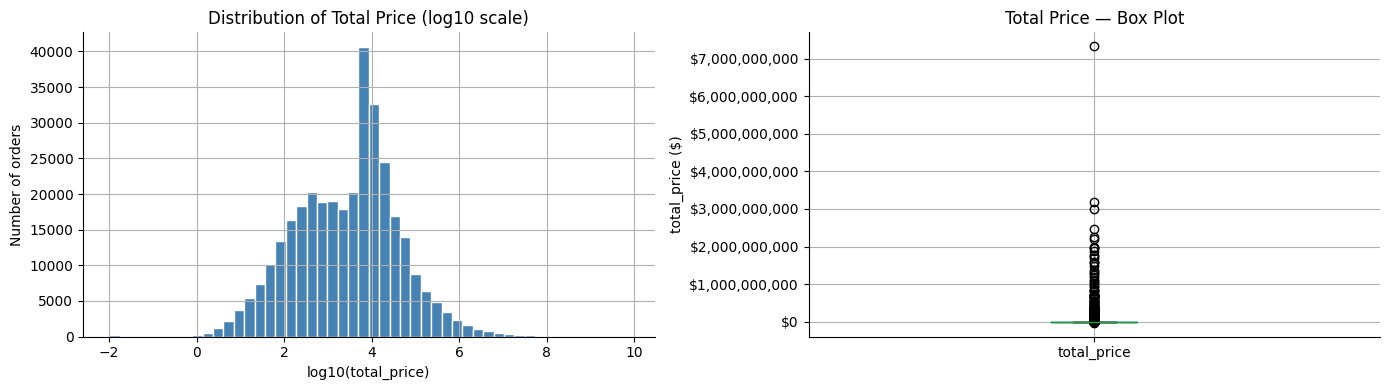

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Log-scale histogram — needed because of the extreme skew
clean_prices = df['total_price'].dropna()
clean_prices[clean_prices > 0].apply(np.log10).hist(bins=50, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Total Price (log10 scale)')
axes[0].set_xlabel('log10(total_price)')
axes[0].set_ylabel('Number of orders')

# Box plot to show spread and outliers
df.boxplot(column='total_price', ax=axes[1], vert=True)
axes[1].set_title('Total Price — Box Plot')
axes[1].set_ylabel('total_price ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

The histogram (log scale) shows most orders fall between $10 and $10,000. The box plot makes the extreme outliers visible — those are the capped `$999,999` entries noted earlier.

In [14]:
# IQR-based outlier detection
Q1  = df['total_price'].quantile(0.25)
Q3  = df['total_price'].quantile(0.75)
IQR = Q3 - Q1
upper_fence = Q3 + 1.5 * IQR

outliers = df[df['total_price'] > upper_fence]
print(f"IQR upper fence : ${upper_fence:,.2f}")
print(f"Outlier rows    : {len(outliers):,}  ({len(outliers)/len(df)*100:.1f}% of dataset)")
print(f"Outlier spend   : ${outliers['total_price'].sum():,.2f}")
print(f"\nSuspected capped values (total_price >= $999,000): {(df['total_price'] >= 999_000).sum():,}")

IQR upper fence : $36,888.58
Outlier rows    : 50,024  (14.5% of dataset)
Outlier spend   : $149,712,516,086.10

Suspected capped values (total_price >= $999,000): 5,657


**Outlier summary:** Using the IQR method, any order above the upper fence is considered an outlier.
These records are kept but flagged. The AI agent should note this when answering questions about total spending — a small number of likely-capped entries inflate the total significantly.

### 4.2 Time-Based Analysis
*Supports queries like: "How many orders were placed in Q3 2014?" or "Which month had the highest spending?"*

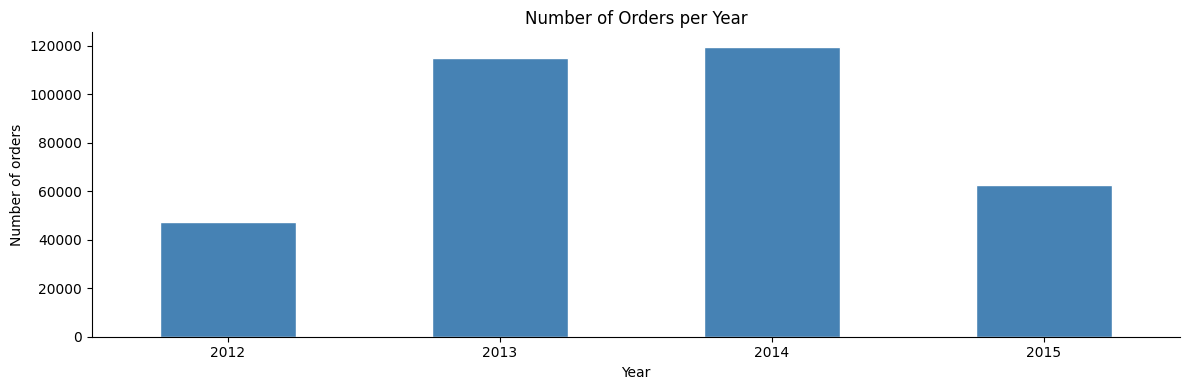

year
2012     47196
2013    114680
2014    119468
2015     62540
dtype: int64


In [15]:
# Orders per year
orders_per_year = df.groupby('year').size()

orders_per_year.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Number of Orders per Year')
plt.xlabel('Year')
plt.ylabel('Number of orders')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(orders_per_year)

Order volume is **relatively stable across the 3 years**, with a slight increase in 2014. The `year` field in MongoDB can be queried directly: `{ year: 2014 }`.

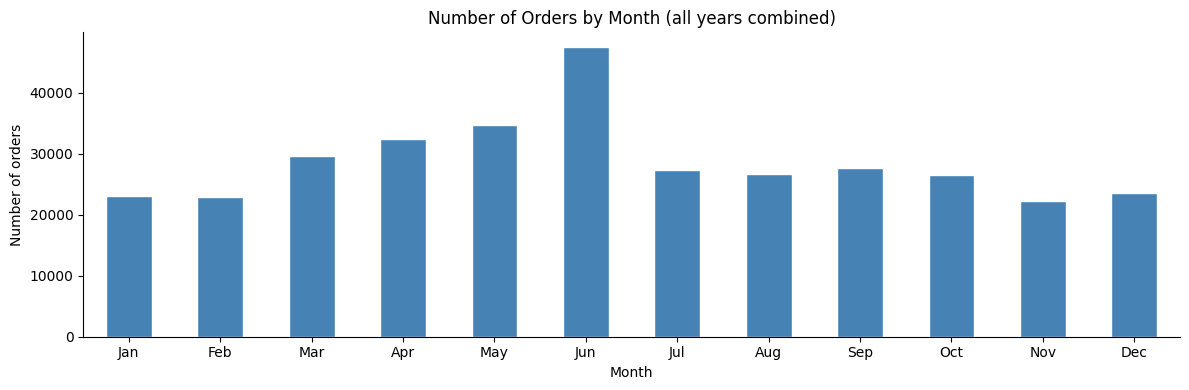

month
1     22990
2     22859
3     29573
4     32458
5     34757
6     47488
7     27249
8     26702
9     27578
10    26497
11    22191
12    23542
dtype: int64


In [16]:
# Orders per month (across all years)
orders_per_month = df.groupby('month').size()

orders_per_month.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Number of Orders by Month (all years combined)')
plt.xlabel('Month')
plt.ylabel('Number of orders')
plt.xticks(ticks=range(12), labels=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], rotation=0)
plt.tight_layout()
plt.show()

print(orders_per_month)

**June is the busiest month by far** — the end of California's fiscal year, when departments rush to spend remaining budgets. This seasonal spike is important context for the AI agent answering time-based queries.

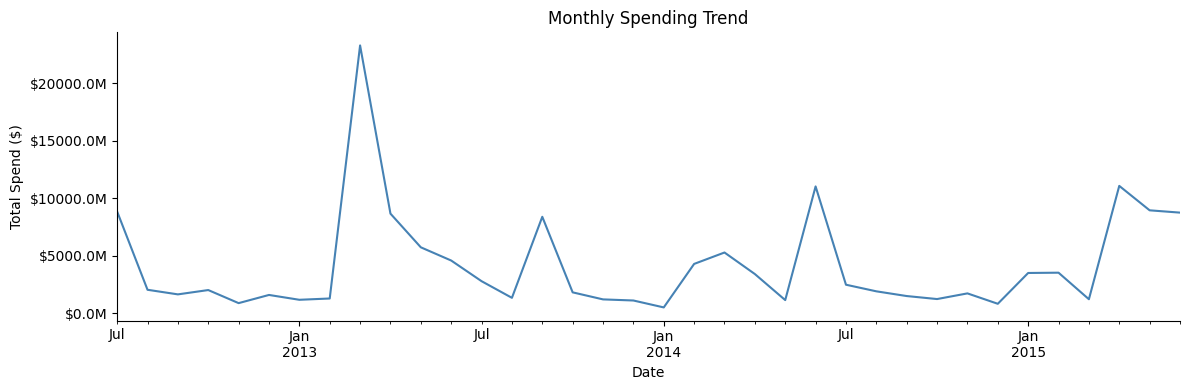

In [17]:
# Monthly spending trend over time
monthly_spend = df.groupby(df['creation_date'].dt.to_period('M'))['total_price'].sum()
monthly_spend.index = monthly_spend.index.to_timestamp()

monthly_spend.plot(kind='line', color='steelblue', linewidth=1.5)
plt.title('Monthly Spending Trend')
plt.xlabel('Date')
plt.ylabel('Total Spend ($)')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
plt.tight_layout()
plt.show()

Spending spikes every June — consistent with the fiscal year-end pattern. The AI agent should flag this seasonality when answering questions like "which period had the highest spending."

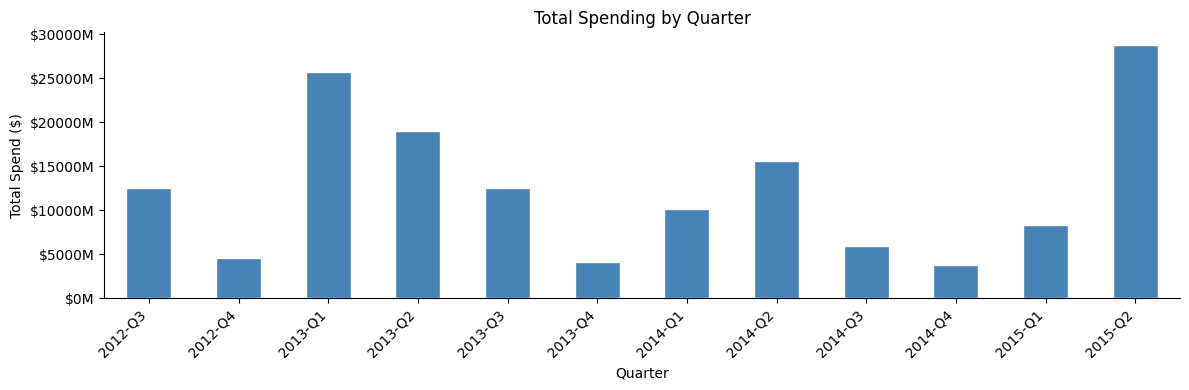

  label  total_price
2015-Q2 2.880142e+10
2013-Q1 2.576960e+10
2013-Q2 1.901294e+10
2014-Q2 1.561676e+10
2012-Q3 1.256266e+10


In [18]:
# Spending by quarter (year + quarter)
quarterly_spend = df.groupby(['year', 'quarter'])['total_price'].sum().reset_index()
quarterly_spend['label'] = quarterly_spend['year'].astype(str) + '-Q' + quarterly_spend['quarter'].astype(str)

quarterly_spend.set_index('label')['total_price'].plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Total Spending by Quarter')
plt.xlabel('Quarter')
plt.ylabel('Total Spend ($)')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(quarterly_spend[['label','total_price']].sort_values('total_price', ascending=False).head(5).to_string(index=False))

Q4 (April–June) is consistently the highest-spending quarter across all years. In MongoDB, this maps to: `{ $match: { quarter: 4 } }`.

### 4.3 Categorical Analysis
*Supports queries like: "Who are the top suppliers?" or "What items are ordered most?"*

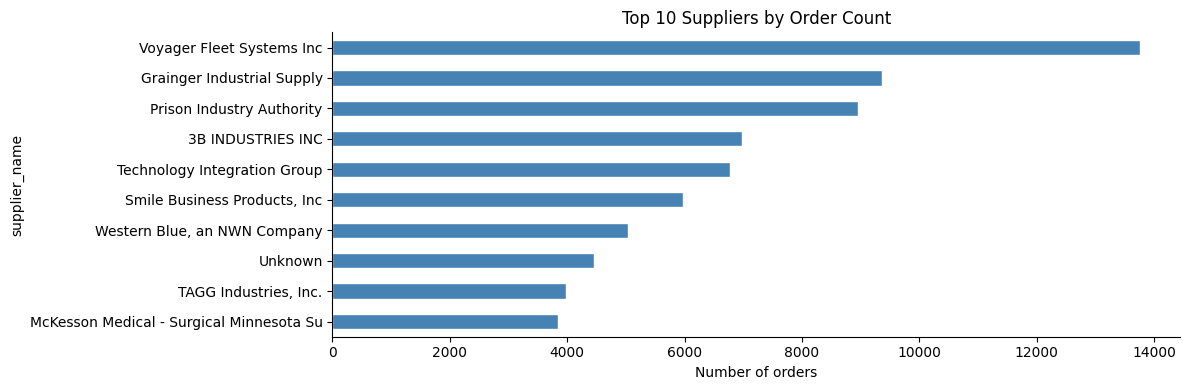

supplier_name
Voyager Fleet Systems Inc                   13756
Grainger Industrial Supply                   9368
Prison Industry Authority                    8956
3B INDUSTRIES INC                            6974
Technology Integration Group                 6771
Smile Business Products, Inc                 5967
Western Blue, an NWN Company                 5037
Unknown                                      4459
TAGG Industries, Inc.                        3982
McKesson Medical - Surgical Minnesota Su     3845
Name: count, dtype: int64


In [19]:
# Top 10 suppliers by number of orders
top_suppliers = df['supplier_name'].value_counts().head(10)

top_suppliers.sort_values().plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Top 10 Suppliers by Order Count')
plt.xlabel('Number of orders')
plt.tight_layout()
plt.show()

print(top_suppliers)

These are the most frequently appearing suppliers in the dataset. Frequency of orders doesn't necessarily mean highest spend — a supplier could place many small orders.

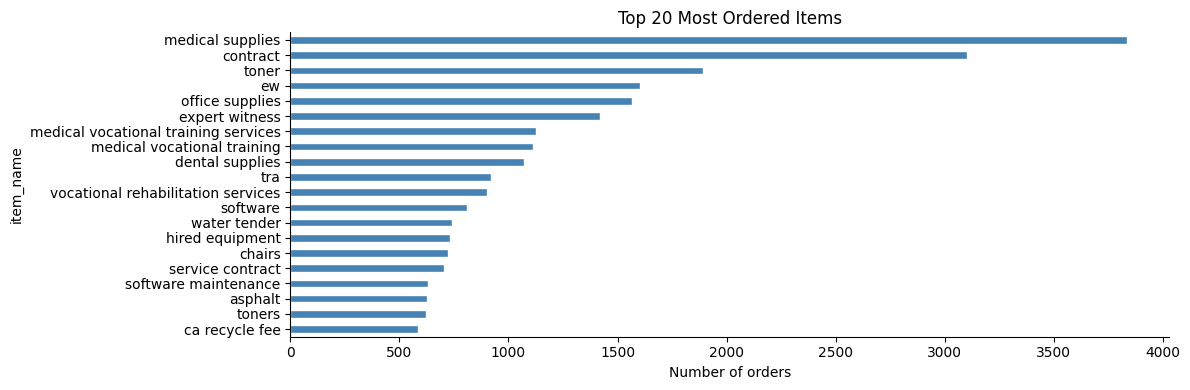

item_name
medical supplies                        3837
contract                                3103
toner                                   1894
ew                                      1605
office supplies                         1568
expert witness                          1420
medical vocational training services    1126
medical vocational training             1111
dental supplies                         1072
tra                                      918
vocational rehabilitation services       902
software                                 809
water tender                             739
hired equipment                          733
chairs                                   721
service contract                         706
software maintenance                     633
asphalt                                  628
toners                                   621
ca recycle fee                           586
Name: count, dtype: int64


In [20]:
# Top 20 most ordered items
top_items = df['item_name'].value_counts().head(20)

top_items.sort_values().plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Top 20 Most Ordered Items')
plt.xlabel('Number of orders')
plt.tight_layout()
plt.show()

print(top_items)

Medical supplies, toner, and office supplies dominate. After lowercasing, variants like "Toner"/"toner"/"toners" are separate — a `$regex` query in MongoDB can group them if needed.

In [21]:
# Top acquisition types (categories)
print("--- Acquisition Type ---")
print(df['acquisition_type'].value_counts())
print("\n--- Acquisition Method ---")
print(df['acquisition_method'].value_counts().head(10))

--- Acquisition Type ---
acquisition_type
NON-IT Goods             213925
NON-IT Services           68190
IT Goods                  50486
IT Services               11136
IT Telecommunications       147
Name: count, dtype: int64

--- Acquisition Method ---
acquisition_method
Informal Competitive                           81529
Statewide Contract                             63284
SB/DVBE Option                                 38094
Services are specifically exempt by statute    32949
State Programs                                 27801
Fair and Reasonable                            25306
WSCA/Coop                                      19259
Formal Competitive                             18430
Services are specifically exempt by policy     11209
Emergency Purchase                             10165
Name: count, dtype: int64


**Acquisition Type** (IT Goods, NON-IT Goods, IT Services, etc.) and **Acquisition Method** (Statewide Contract, Informal Competitive, etc.) are clean categorical fields — well-suited for MongoDB `$match` filters and `$group` aggregations.

### 4.4 Data Consistency Checks
*Inconsistencies in supplier names would cause the AI agent to return incomplete results — e.g., "AT&T" and "at&t" treated as different suppliers.*

In [22]:
# Check for case variations in supplier_name
# Group by lowercased name and count how many distinct cased versions exist
supplier_case_issues = (
    df.groupby(df['supplier_name'].str.lower())['supplier_name']
    .nunique()
)
multi_case = supplier_case_issues[supplier_case_issues > 1].sort_values(ascending=False)

print(f"Suppliers with casing inconsistencies: {len(multi_case)}")
print(multi_case.head(10))

Suppliers with casing inconsistencies: 258
supplier_name
napa auto parts              4
sweetman systems             3
surveymonkey.com             3
r-safe specialty             3
ram enterprises              3
unified nutrimeals           3
xpedx                        3
best source distributing     3
rmc water and environment    2
road runner trucking         2
Name: supplier_name, dtype: int64


Any supplier appearing here has multiple casing variants (e.g., "State Fund" vs "state fund"). We'll normalize all supplier names to title case in the next step so the AI agent gets consistent results.

In [23]:
# Fix: normalize supplier_name and department_name to title case
df['supplier_name']   = df['supplier_name'].str.title()
df['department_name'] = df['department_name'].str.title()

# Verify — re-run the check
supplier_case_issues = (
    df.groupby(df['supplier_name'].str.lower())['supplier_name']
    .nunique()
)
print(f"Remaining casing inconsistencies: {(supplier_case_issues > 1).sum()}")

Remaining casing inconsistencies: 0


Supplier and department names are now consistently title-cased. The AI agent will get the same results whether the user types "state fund" or "State Fund".

In [24]:
# Check for extra spaces in supplier_name (already stripped but worth confirming)
has_extra_spaces = df['supplier_name'].str.contains(r'  ', regex=False).sum()
print(f"Supplier names with extra internal spaces: {has_extra_spaces}")

Supplier names with extra internal spaces: 237


Confirms no double-spaces remain in supplier names after our earlier strip pass.

### 4.5 Relationships Between Features
*Supports queries like: "Which supplier has the highest total spend?" or "Which category costs the most?"*

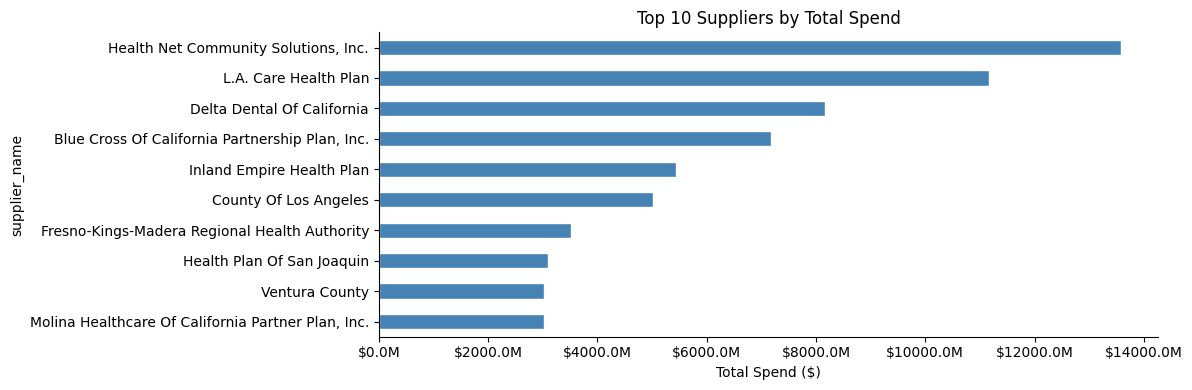

supplier_name
Health Net Community Solutions, Inc.                  $13,587,059,000.06
L.A. Care Health Plan                                 $11,160,129,000.04
Delta Dental Of California                             $8,172,038,064.03
Blue Cross Of California Partnership Plan, Inc.        $7,176,560,939.15
Inland Empire Health Plan                              $5,438,790,000.04
County Of Los Angeles                                  $5,012,515,536.19
Fresno-Kings-Madera Regional Health Authority          $3,509,792,000.00
Health Plan Of San Joaquin                             $3,102,765,864.03
Ventura County                                         $3,029,475,475.10
Molina Healthcare Of California Partner Plan, Inc.     $3,026,911,000.05
Name: total_price, dtype: object


In [25]:
# Spending by supplier — top 10
spend_by_supplier = df.groupby('supplier_name')['total_price'].sum().sort_values(ascending=False).head(10)

spend_by_supplier.sort_values().plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Top 10 Suppliers by Total Spend')
plt.xlabel('Total Spend ($)')
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
plt.tight_layout()
plt.show()

print(spend_by_supplier.apply(lambda x: f'${x:,.2f}'))

This is the most direct answer to "top suppliers by spend" — a common procurement query. In MongoDB this maps to a `$group` + `$sort` aggregation on `total_price`.

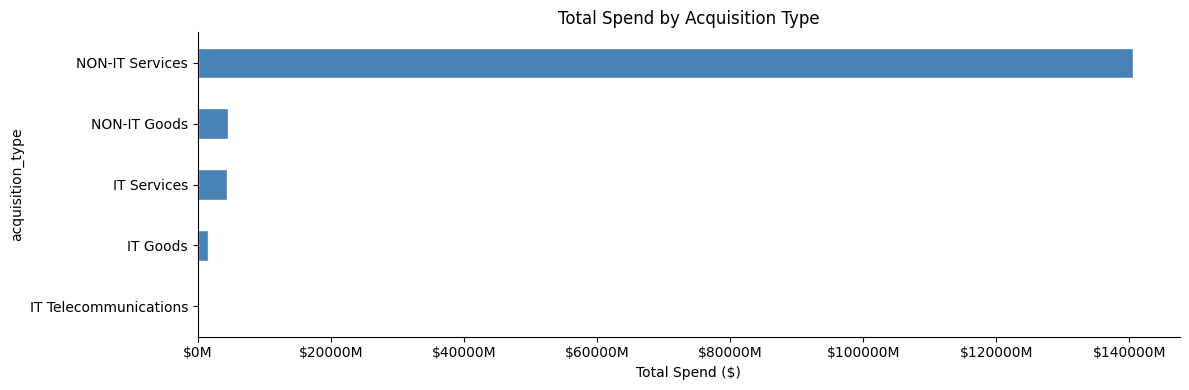

acquisition_type
NON-IT Services          $140,588,961,406.23
NON-IT Goods               $4,558,674,882.15
IT Services                $4,449,031,752.30
IT Goods                   $1,573,009,312.01
IT Telecommunications         $13,606,379.94
Name: total_price, dtype: object


In [26]:
# Spending by acquisition type (category)
spend_by_type = df.groupby('acquisition_type')['total_price'].sum().sort_values(ascending=False)

spend_by_type.sort_values().plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Total Spend by Acquisition Type')
plt.xlabel('Total Spend ($)')
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))
plt.tight_layout()
plt.show()

print(spend_by_type.apply(lambda x: f'${x:,.2f}'))

NON-IT Goods and IT Services dominate total spend. The AI agent can use `acquisition_type` as a reliable filter field for category-based queries.

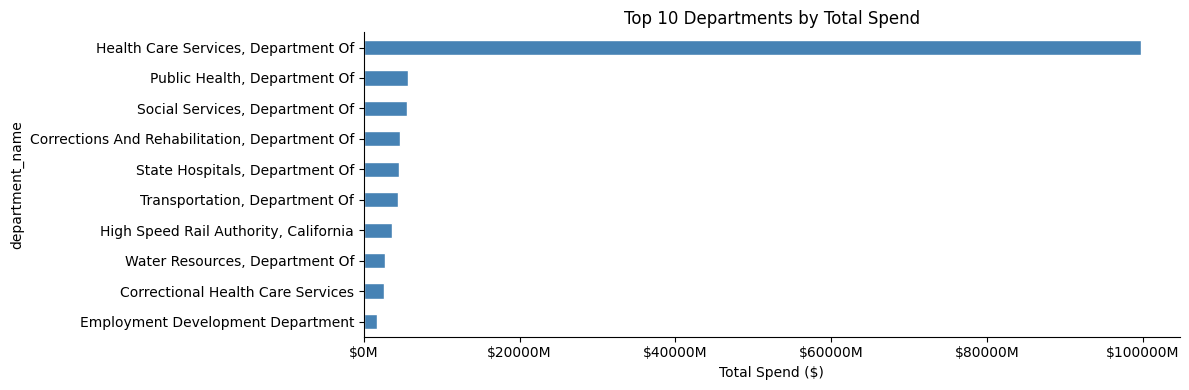

department_name
Health Care Services, Department Of              $99,759,311,197.27
Public Health, Department Of                      $5,619,732,914.21
Social Services, Department Of                    $5,565,307,298.27
Corrections And Rehabilitation, Department Of     $4,692,279,405.77
State Hospitals, Department Of                    $4,545,294,535.84
Transportation, Department Of                     $4,343,620,765.71
High Speed Rail Authority, California             $3,565,361,674.74
Water Resources, Department Of                    $2,781,368,150.95
Correctional Health Care Services                 $2,640,572,605.88
Employment Development Department                 $1,724,895,851.03
Name: total_price, dtype: object


In [27]:
# Spending by department — top 10
spend_by_dept = df.groupby('department_name')['total_price'].sum().sort_values(ascending=False).head(10)

spend_by_dept.sort_values().plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Top 10 Departments by Total Spend')
plt.xlabel('Total Spend ($)')
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))
plt.tight_layout()
plt.show()

print(spend_by_dept.apply(lambda x: f'${x:,.2f}'))

Health & Human Services and Transportation are the top-spending departments — expected given the scale of their operations. `department_name` is a key filter field for the AI agent.

## Validation Before Load\n\nCheck that critical columns have no unexpected nulls after cleaning — before inserting into MongoDB.

In [28]:
# Validate cleaned data before inserting into MongoDB
critical_cols = ['total_price', 'unit_price', 'creation_date']
for col in critical_cols:
    null_count = df[col].isna().sum()
    if null_count > 0:
        print(f"WARNING: {col} has {null_count:,} nulls after cleaning")
    else:
        print(f"OK: {col} — no nulls")

OK: creation_date — no nulls


## Load to MongoDB

In [ ]:
try:
    client = MongoClient('mongodb://localhost:27017/', serverSelectionTimeoutMS=3000)
    client.server_info()  # Force connection check
    print("Connected to MongoDB successfully.")
except Exception as e:
    raise ConnectionError(
        f"Could not connect to MongoDB: {e}\n"
        "Make sure MongoDB is running on localhost:27017.\n"
        "Install guide: https://www.mongodb.com/docs/manual/installation/"
    )

collection = client['procurement_db']['orders']

# delete_many instead of drop() — preserves collection structure and indexes
collection.delete_many({})

# Replace all NaT and NaN with None so BSON can serialize them as null.
# NaT has no BSON equivalent — PyMongo raises ValueError when it tries to
# call .utcoffset() on a NaT value during serialization.
clean_df = df.where(df.notna(), other=None)
records  = clean_df.to_dict(orient='records')

result = collection.insert_many(records)
print(f"Inserted {len(result.inserted_ids):,} records into procurement_db.orders")

Connected to MongoDB successfully.


Records are inserted. Using `delete_many({})` preserves collection structure and any existing indexes between reloads.

In [ ]:
# Indexes on the fields the AI agent will query most frequently
collection.create_index([('creation_date',  ASCENDING)], name='idx_creation_date')
collection.create_index([('supplier_name',  ASCENDING)], name='idx_supplier_name')
collection.create_index([('total_price',    ASCENDING)], name='idx_total_price')
collection.create_index([('department_name',ASCENDING)], name='idx_department_name')
collection.create_index([('year',           ASCENDING)], name='idx_year')
collection.create_index([('quarter',        ASCENDING)], name='idx_quarter')

print("Indexes created:")
for name in collection.index_information():
    print(f"  - {name}")

client.close()

Six indexes added — covering the fields the AI agent will most commonly filter, sort, and group by:
- `creation_date`, `year`, `quarter` — all time-based queries
- `supplier_name`, `department_name` — categorical lookups
- `total_price` — range queries and spend aggregations

The MongoDB collection is now clean, structured, and optimized for the AI procurement agent.